In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

## DBSCAN Clustering on `Mall_Customers.csv`

### Data Cleaning (Revisiting `Mall_Customers.csv`)

Although we previously checked for missing values and found none, it's good practice to ensure data quality before proceeding with new analysis. We will also inspect for duplicates.

In [27]:
# Check for duplicates
duplicates = df_mall.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    df_mall.drop_duplicates(inplace=True)
    print(f"DataFrame shape after removing duplicates: {df_mall.shape}")
else:
    print("No duplicate rows found.")

print("\nMissing values after cleaning (re-check):")
display(df_mall.isnull().sum())

Number of duplicate rows: 0
No duplicate rows found.

Missing values after cleaning (re-check):


,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0
Cluster,0


### Exploratory Data Analysis (EDA) for DBSCAN

For DBSCAN, it's helpful to visualize the distribution of the features we plan to cluster. This can give us an idea of potential density-based clusters and help in selecting `eps` and `min_samples` parameters.

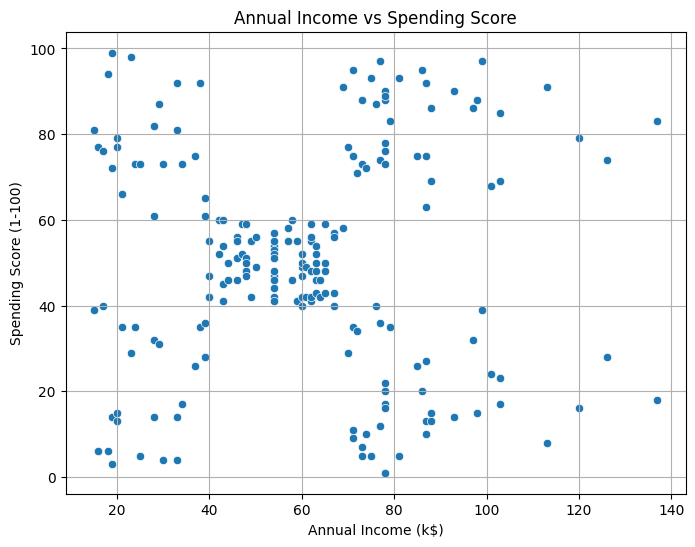

In [28]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df_mall)
plt.title('Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True)
plt.show()

### Prepare Data for DBSCAN

As with Hierarchical Clustering, we'll use 'Annual Income (k$)' and 'Spending Score (1-100)'. We already have a scaled version of these features as `X_scaled` from previous steps, which is suitable for DBSCAN.

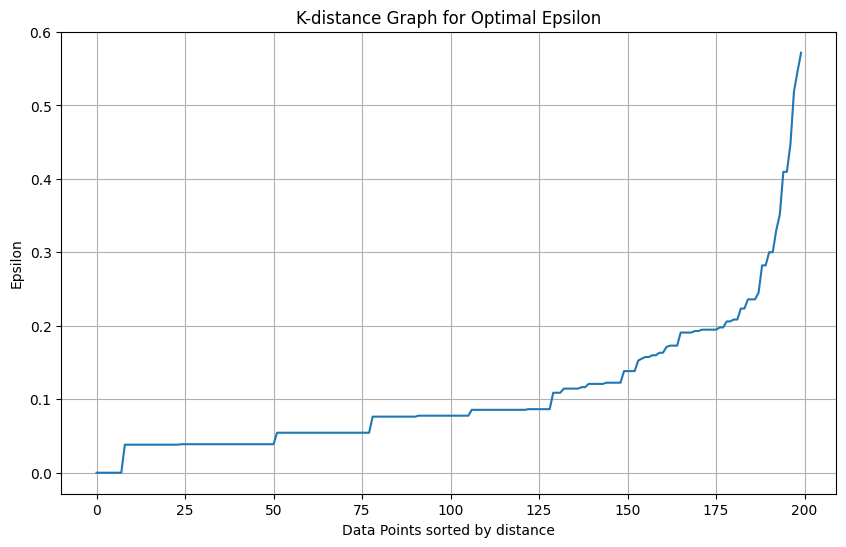

Look for the 'elbow' point in the graph above to determine an appropriate `eps` value.
A common approach is to pick the value where the sharpest bend occurs.


In [35]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# Determine optimal eps using K-distance graph
# This step helps in choosing a good value for eps
neigh = NearestNeighbors(n_neighbors=2)
nbrs = neigh.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

distances = np.sort(distances[:, 1], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title('K-distance Graph for Optimal Epsilon')
plt.xlabel('Data Points sorted by distance')
plt.ylabel('Epsilon')
plt.grid(True)
plt.show()

print("Look for the 'elbow' point in the graph above to determine an appropriate `eps` value.")
print("A common approach is to pick the value where the sharpest bend occurs.")

#### Apply DBSCAN

Based on the K-distance graph, let's choose an `eps` value. For `min_samples`, a common rule of thumb is `2 * number_of_dimensions`. Here, we have 2 dimensions, so `min_samples=4` is a good starting point.

In [33]:
# Let's assume an eps value of around 0.3-0.5 based on typical elbow points seen in such graphs.
# I'll use 0.4 as an initial guess, but this might need fine-tuning based on the generated plot.
dbscan = DBSCAN(eps=0.4, min_samples=4) # Adjust eps and min_samples based on K-distance graph and domain knowledge
clusters_dbscan = dbscan.fit_predict(X_scaled)

df_mall['DBSCAN_Cluster'] = clusters_dbscan

print("DBSCAN Cluster distribution:")
display(df_mall['DBSCAN_Cluster'].value_counts())

# The value -1 usually indicates noise points

DBSCAN Cluster distribution:


,count
DBSCAN_Cluster,
0,126
1,33
2,27
-1,14


### Visualize DBSCAN Clustering Results

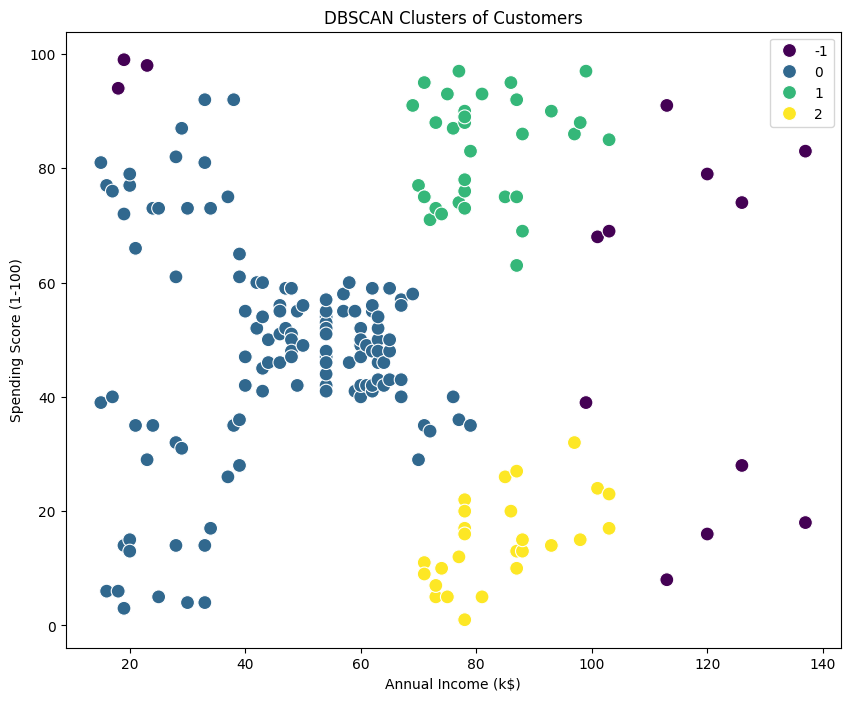

In [34]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='DBSCAN_Cluster', data=df_mall, palette='viridis', s=100)
plt.title('DBSCAN Clusters of Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

In [26]:
from google.colab import files
uploaded=files.upload()

Saving Wholesale customers data.csv to Wholesale customers data.csv
